# Introducción

El presente análisis se divide en dos partes. En la primera se priorizan nueve hipótesis de mejora para una tienda online utilizando los frameworks ICE y RICE, determinando cuáles tienen mayor potencial de impacto considerando alcance, impacto, confianza y esfuerzo. En la segunda se analizan los resultados de un test A/B realizado durante agosto de 2019, evaluando diferencias en conversión y tamaño promedio de pedido entre los grupos A y B, con el objetivo de decidir si implementar los cambios probados de forma permanente.

# Preparación de los datos

Importamos nuestras librerías y cargamos los DataFrames

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats as st

In [3]:
hypotheses = pd.read_csv("datasets/hypotheses_us.csv", sep=";")
orders = pd.read_csv("datasets/orders_us.csv")
visits = pd.read_csv("datasets/visits_us.csv")

# Exploración de los datos

Utilizamos los métodos .info(), .head() y .tail() en cada uno de nuestros DataFrames para familiarizarnos con nuestros datos y buscamos duplicados en los DataFrames `orders` y `visits`

## hypotheses

In [4]:
hypotheses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 492.0+ bytes


In [5]:
hypotheses.head()

,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1


In [6]:
hypotheses.tail()

,Hypothesis,Reach,Impact,Confidence,Effort
4,Change the background color on the main page. ...,3,1,1,1
5,Add a customer review page. This will increase...,3,2,2,3
6,Show banners with current offers and sales on ...,5,3,8,3
7,Add a subscription form to all the main pages....,10,7,8,5
8,Launch a promotion that gives users discounts ...,1,9,9,5


El DataFrame contiene diferentes hipótesis planteadas por el departamento de marketing junto con calificaciones en una escala del 1 al 10 de su alcance, impacto, confianza en que funcionara y esfuerzo que conllevara realizar la acción citada.

Los nombres de las columnas deberán pasarse a minúsculas.

## orders

In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB


In [8]:
orders.head()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


In [9]:
orders.tail()

,transactionId,visitorId,date,revenue,group
1192,2662137336,3733762160,2019-08-14,100.8,B
1193,2203539145,370388673,2019-08-14,50.1,A
1194,1807773912,573423106,2019-08-14,165.3,A
1195,1947021204,1614305549,2019-08-14,5.5,A
1196,3936777065,2108080724,2019-08-15,3120.1,B


Buscamos datos duplicados

In [10]:
orders.duplicated().sum()

np.int64(0)

In [11]:
# Agrupamos nuestro dataframe por visitante y buscamos cuantos grupos unicos tiene cada uno
users_in_both_groups = orders.groupby("visitorId")["group"].nunique()

# Filtramos a los usuarios que aparecen en más de un grupo
users_in_both_groups = users_in_both_groups[users_in_both_groups > 1]

print(f"Usuarios en ambos grupos: {len(users_in_both_groups)}")

Usuarios en ambos grupos: 58


El dataframe `orders` contiene información sobre las compras realizadas por usuarios divididos en dos grupos (A y B). Consta de 1197 registros y 5 columnas a las cuales debemos renombrar para que cumplan con el formato snake_case (`transactionId`, `visitorId`, `date`, `revenue`, `group`) 

También es necesario convertir el tipo de datos de la columna `date` a datetime. 

No existen duplicados explícitos pero existen 58 usuarios que aparecen en ambos grupos.

## visits

In [12]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


In [13]:
visits.head()

,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [14]:
visits.tail()

,date,group,visits
57,2019-08-27,B,720
58,2019-08-28,B,654
59,2019-08-29,B,531
60,2019-08-30,B,490
61,2019-08-31,B,718


In [15]:
visits.duplicated().sum()

np.int64(0)

El DataFrame `visits` contiene el registro de las visitas realizadas por los usuarios de cada grupo por día.

No existen valores duplicados. 

Es necesario cambiar le tipo de datos de la columna `date` a datetime

# Procesamiento de los datos

## hypotheses

Cambiamos el nombre de las columnas del DataFrame `hypotheses`

In [16]:
hypotheses.columns = hypotheses.columns.str.lower()

hypotheses.columns

Index(['hypothesis', 'reach', 'impact', 'confidence', 'effort'], dtype='object')

## orders

Cambiamos el nombre de las columnas del DataFrame `orders`

In [17]:
orders.columns = ["transaction_id", "visitor_id", "date", "revenue", "group"]

orders.columns

Index(['transaction_id', 'visitor_id', 'date', 'revenue', 'group'], dtype='object')

Cambiamos el tipo de datos de la columna `date`

In [18]:
orders["date"] = pd.to_datetime(orders["date"])

print(orders["date"].dtype)

datetime64[ns]


Filtramos a los usuarios que aparecen en ambos grupos 

In [19]:
orders_clean = orders[~orders["visitor_id"].isin(users_in_both_groups.index)]

In [20]:
# Revisamos la cantidad de usuarios en cada grupo después de la limpieza
users_by_group = orders_clean.groupby("group")["visitor_id"].nunique()

print(users_by_group)

group
A    445
B    528
Name: visitor_id, dtype: int64


Tras eliminar los 58 usuarios contaminados, el grupo A quedó con 445 usuarios únicos y el grupo B con 528. La diferencia es aceptable para continuar con el análisis.

## visits

Cambiamos el tipo de datos de la columna `date`

In [21]:
visits["date"] = pd.to_datetime(visits["date"])

print(visits["date"].dtype)

datetime64[ns]


# Parte 1: Priorización de hipótesis

In [22]:
hypotheses.columns

Index(['hypothesis', 'reach', 'impact', 'confidence', 'effort'], dtype='object')

## Framework ICE

In [23]:
# Agregamos la columna "ice" con el calculo correspondiente

hypotheses["ice"] = hypotheses["impact"] * hypotheses["confidence"] / hypotheses["effort"]

hypotheses.sort_values(by="ice", ascending=False)

,hypothesis,reach,impact,confidence,effort,ice
8,Launch a promotion that gives users discounts ...,1,9,9,5,16.200000
0,Add two new channels for attracting traffic. T...,3,10,8,6,13.333333
7,Add a subscription form to all the main pages....,10,7,8,5,11.200000
6,Show banners with current offers and sales on ...,5,3,8,3,8.000000
2,Add product recommendation blocks to the store...,8,3,7,3,7.000000
1,Launch your own delivery service. This will sh...,2,5,4,10,2.000000
5,Add a customer review page. This will increase...,3,2,2,3,1.333333
3,Change the category structure. This will incre...,8,3,3,8,1.125000
4,Change the background color on the main page. ...,3,1,1,1,1.000000


## Framework RICE

In [24]:
# Agregamos la columna "rice" con el calculo correspondiente

hypotheses["rice"] = hypotheses["reach"] * hypotheses["impact"] * hypotheses["confidence"] / hypotheses["effort"]

hypotheses.sort_values(by="rice", ascending=False)

,hypothesis,reach,impact,confidence,effort,ice,rice
7,Add a subscription form to all the main pages....,10,7,8,5,11.200000,112.0
2,Add product recommendation blocks to the store...,8,3,7,3,7.000000,56.0
0,Add two new channels for attracting traffic. T...,3,10,8,6,13.333333,40.0
6,Show banners with current offers and sales on ...,5,3,8,3,8.000000,40.0
8,Launch a promotion that gives users discounts ...,1,9,9,5,16.200000,16.2
3,Change the category structure. This will incre...,8,3,3,8,1.125000,9.0
1,Launch your own delivery service. This will sh...,2,5,4,10,2.000000,4.0
5,Add a customer review page. This will increase...,3,2,2,3,1.333333,4.0
4,Change the background color on the main page. ...,3,1,1,1,1.000000,3.0


## Conclusión

La priorización cambia significativamente al incorporar el factor de alcance en RICE. La hipótesis 8, que lidera el ranking ICE por su alto impacto y confianza, cae al quinto lugar en RICE debido a su alcance mínimo (1/10). En contraste, la hipótesis 7 sube al primer lugar porque combina alto alcance (10/10) con buen impacto y confianza.

Para una tienda online donde el objetivo es maximizar ingresos a escala, RICE es el framework más adecuado ya que una hipótesis de alto impacto pero bajo alcance genera menos valor de negocio que una de impacto moderado pero alcance masivo.

# Parte 2: Análisis del test A/B

## Ingreso acumulado por grupo

Para esta parte del análisis crearemos el DataFrame `cumulative_data` el cual contendrá información sobre los ingresos y visitantes acumulados de cada grupo

Para obtener los ingresos acumulados de cada grupo comenzaremos por crear una matriz que contenga pares de grupos y fechas sin duplicados

In [25]:
date_groups = orders[["date", "group"]].drop_duplicates()

Realizamos el calculo de los ingresos acumulados apoyandonos de las funciones *lambda* y *np.logical_and()*

In [26]:
orders_aggregated = date_groups.apply(lambda x: orders_clean[np.logical_and(orders_clean["date"] <= x["date"], orders_clean["group"] == x["group"])].agg(
    {"date": "max", "group": "max", "transaction_id": pd.Series.nunique, "visitor_id": pd.Series.nunique, "revenue": "sum"}
), axis=1).sort_values(by=["date", "group"])

Seguimos el mismo proceso para las visitas

In [27]:
visits_aggregated = date_groups.apply(lambda x: visits[np.logical_and(visits["date"] <= x["date"], visits["group"] == x["group"])].agg(
    {"date": "max", "group": "max", "visits": "sum"}
), axis=1).sort_values(by=["date", "group"])

Unimos ambos DataFrames en uno solo: `cumulative_data`

In [28]:
cumulative_data = orders_aggregated.merge(visits_aggregated, left_on=["date", "group"], right_on=["date", "group"])

cumulative_data.columns = ["date", "group", "orders", "buyers", "revenue", "visits"]

A continuación, creamos nuestro gráfico de ingresos acumulados

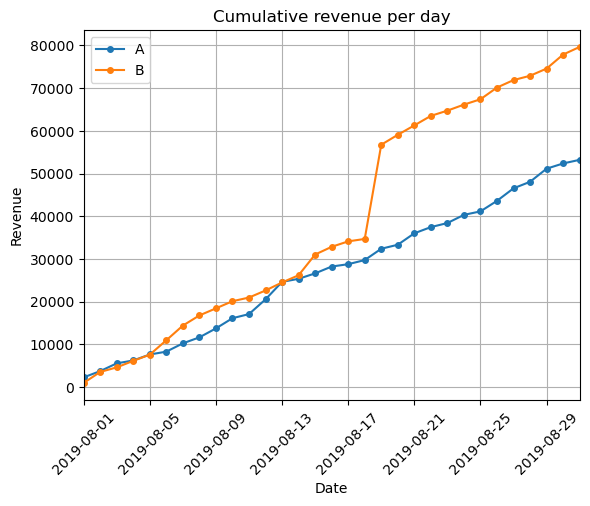

In [29]:
# DataFrame con pedidos e ingresos acumulados por dia del grupo A
cumulative_revenue_a = cumulative_data[cumulative_data["group"] == "A"][["date", "revenue","orders"]]

# DataFrame con pedidos e ingresos acumulados por dia del grupo B
cumulative_revenue_b = cumulative_data[cumulative_data["group"] == "B"][["date", "revenue","orders"]]

# Generamos el gráfico

plt.plot(cumulative_revenue_a["date"], cumulative_revenue_a["revenue"], marker="o", markersize=4, label="A")
plt.plot(cumulative_revenue_b["date"], cumulative_revenue_b["revenue"], marker="o", markersize=4, label="B")

plt.title("Cumulative revenue per day")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.xlim(pd.Timestamp("2019-08-01"), pd.Timestamp("2019-08-31"))
plt.grid()
plt.legend()



plt.show()

Ambos grupos inician con ingresos similares, sin embargo el grupo B mantiene un crecimiento acumulado mayor a lo largo del período. Se observa un salto abrupto en el ingreso acumulado del grupo B alrededor del 19 de agosto, lo que sugiere una o varias transacciones atípicamente grandes que distorsionan la comparación.

Antes de concluir que el grupo B es superior, es necesario revisar el tamaño promedio de las órdenes y los valores atípicos de ese período, ya que un solo pedido de alto valor puede inflar el ingreso acumulado sin representar una mejora real en el comportamiento general de los usuarios.

## Pedido promedio acumulado por grupo

Trazamos nuestro gráfico dividiendo el ingreso entre los pedidos realizados por día

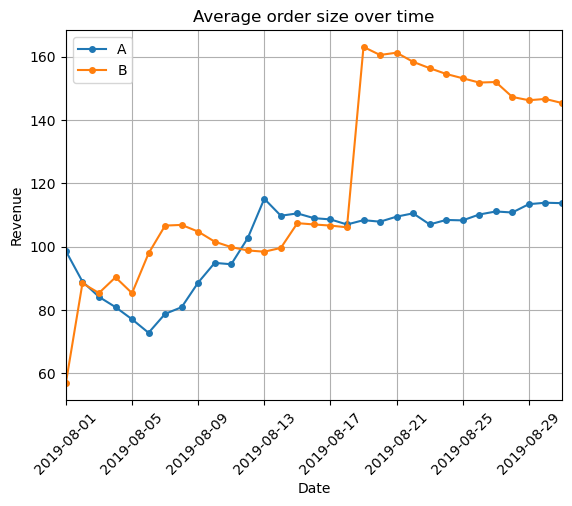

In [30]:
plt.plot(cumulative_revenue_a["date"], cumulative_revenue_a["revenue"]/cumulative_revenue_a["orders"], marker="o", markersize=4, label="A")
plt.plot(cumulative_revenue_b["date"], cumulative_revenue_b["revenue"]/cumulative_revenue_b["orders"], marker="o", markersize=4, label="B")

plt.title("Average order size over time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.xlim(pd.Timestamp("2019-08-01"), pd.Timestamp("2019-08-31"))
plt.grid()
plt.legend()



plt.show()

Durante los primeros días del período, ambos grupos muestran alta variabilidad en el ticket promedio acumulado, lo cual es esperado dado el volumen reducido de datos iniciales.
El pico del 19 de agosto en el grupo B confirma la presencia de transacciones atípicamente grandes. La aparente caída posterior no representa una reducción real en el comportamiento de compra, sino una estabilización del promedio al no repetirse valores similares.

El grupo A muestra una tendencia de crecimiento más gradual y estable, con fluctuaciones menores que sugieren una distribución más homogénea de los valores de compra. Al cierre del período, ambos grupos se estabilizan, aunque el grupo B mantiene un ticket promedio acumulado considerablemente mayor, influenciado por las transacciones atípicas del 19 de agosto.
Es necesario analizar y filtrar estos valores atípicos antes de sacar conclusiones sobre la superioridad real del grupo B.

## Diferencia relativa en el tamaño de pedido promedio

Para realizar este calculo sera necesario unir nuestros DataFrames `cumulative_revenue_a` y `cumulative_revenue_b`

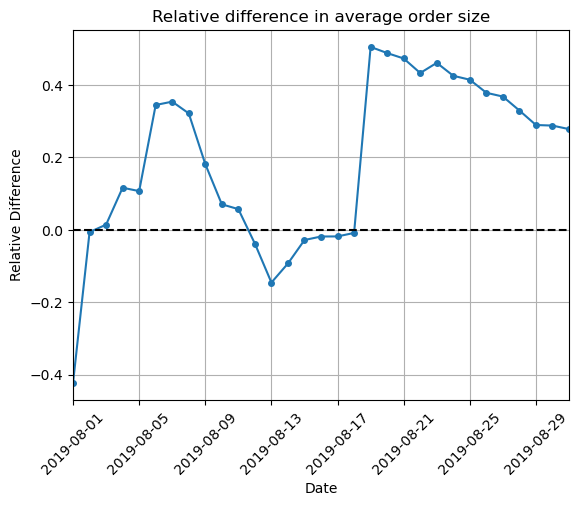

In [31]:
merged_cumulative_revenues = cumulative_revenue_a.merge(cumulative_revenue_b, left_on="date", right_on="date", how="left", suffixes=["A", "B"])

# Trazamos nuestro gráfico
plt.plot(merged_cumulative_revenues["date"], (merged_cumulative_revenues["revenueB"]/merged_cumulative_revenues["ordersB"])/(merged_cumulative_revenues["revenueA"]/merged_cumulative_revenues["ordersA"])-1, marker="o", markersize=4)

plt.title("Relative difference in average order size")
plt.xlabel("Date")
plt.ylabel("Relative Difference")
plt.xticks(rotation=45)
plt.xlim(pd.Timestamp("2019-08-01"), pd.Timestamp("2019-08-31"))
plt.axhline(y=0, color="black", linestyle="--")
plt.grid()


plt.show()

El grupo B mantiene una ventaja positiva sobre el grupo A durante la mayor parte del período, con excepción de los días 12 al 18 de agosto donde el grupo A superó brevemente al B. A partir del 19 de agosto, la diferencia relativa se dispara hasta ~48%, impulsada por las transacciones atípicas identificadas anteriormente.

Esta ventaja no refleja necesariamente un comportamiento superior del grupo B: al filtrar los valores atípicos del 19 de agosto, es probable que la diferencia real sea considerablemente menor. La tendencia descendente observada al final del período sugiere que, sin el efecto de esas transacciones, la brecha entre grupos podría ser mucho más estrecha.

## Tasa de conversión acumulada

Calculamos la tasa de conversión acumulada y trazamos nuestro gráfico

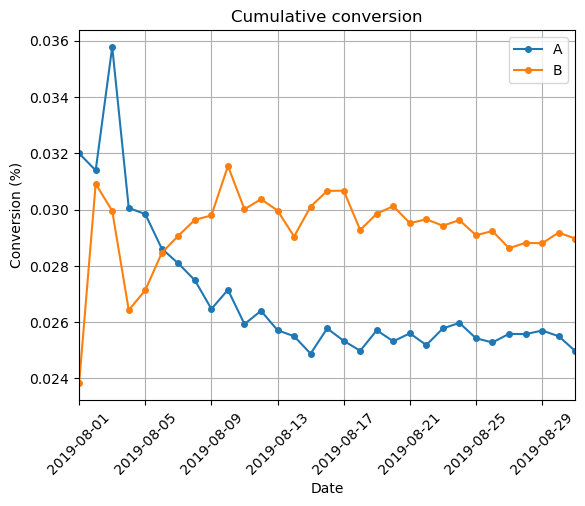

In [32]:
cumulative_data["conversion"] = cumulative_data["orders"]/cumulative_data["visits"]

# Filtramos los datos de los grupos A y B
cumulative_data_a = cumulative_data[cumulative_data["group"] == "A"]
cumulative_data_b = cumulative_data[cumulative_data["group"] == "B"]

# Generamos nuestro gráfico
plt.plot(cumulative_data_a["date"], cumulative_data_a["conversion"], marker="o", markersize=4, label="A")
plt.plot(cumulative_data_b["date"], cumulative_data_b["conversion"], marker="o", markersize=4, label="B")

plt.title("Cumulative conversion")
plt.xlabel("Date")
plt.ylabel("Conversion (%)")
plt.xticks(rotation=45)
plt.xlim(pd.Timestamp("2019-08-01"), pd.Timestamp("2019-08-31"))
plt.grid()
plt.legend()



plt.show()

El grupo B mantiene una tasa de conversión consistentemente superior al grupo A la mayor parte del período, incluso antes del pico del 19 de agosto. El hecho de que ese día no generara un salto en la conversión sugiere que el incremento en ingresos provino de pocas transacciones de alto valor y no de un aumento en compradores.

Las fluctuaciones en ambas curvas indican que el test aún no ha alcanzado estabilidad suficiente para sacar conclusiones definitivas.

## Gráfico de dispersión y percentiles de pedidos por usuario

Para trazar nuestro gráfico agrupamos nuestro DataFrame `orders_clean` por usuario y contamos el numero único de pedidos realizado por cada uno

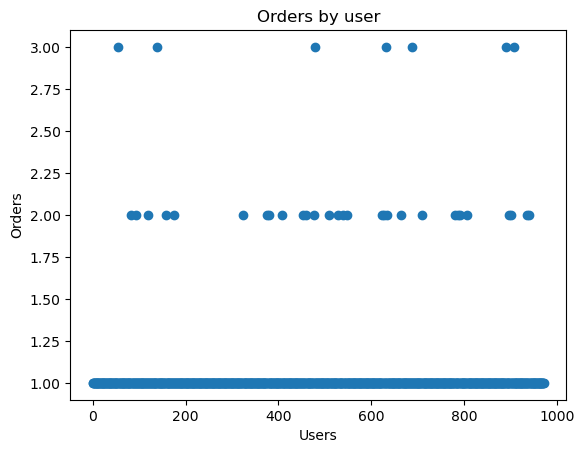

In [33]:
orders_by_user = orders_clean.groupby("visitor_id", as_index=False).agg({"transaction_id": pd.Series.nunique})

# Renombramos las columnas
orders_by_user.columns = ["visitor_id", "orders"]

# Establecemos cuanto abarcara nuestro eje X
x_values = pd.Series(range(0, len(orders_by_user)))

# Trazamos nuestro gráfico
plt.scatter(x_values, orders_by_user["orders"])

plt.title("Orders by user")
plt.xlabel("Users")
plt.ylabel("Orders")

plt.show()

Calculamos los percentiles 95 y 99 del número de pedidos por usuario para definir el umbral a partir del cual un usuario se considera atípico.

In [34]:
print(np.percentile(orders_by_user["orders"], [95, 99]))

[1. 2.]


Los percentiles 95 y 99 del número de pedidos por usuario son 1 y 2 respectivamente, lo que indica que el 99% de los usuarios realizó 2 pedidos o menos durante el período. Se consideran atípicos los usuarios con 3 o más pedidos, representando el top 1% de la distribución.

Adicionalmente, es necesario revisar la distribución de precios de los pedidos para identificar transacciones de alto valor que puedan estar distorsionando las métricas de ingreso.

## Gráfico de dispersión y percentiles de el precio de los pedidos

Trazamos un gráfico de dispersión para visualizar la distribución de los precios de los pedidos e identificar transacciones atípicas.

Text(0, 0.5, 'Revenue')

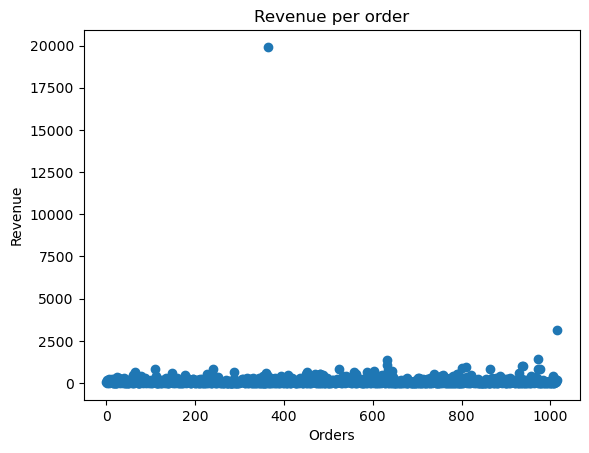

In [35]:
x_values_prices = pd.Series(range(0, len(orders_clean)))

plt.scatter(x_values_prices, orders_clean["revenue"])

plt.title("Revenue per order")
plt.xlabel("Orders")
plt.ylabel("Revenue")

Calculamos los percentiles 95 y 99 del precio de los pedidos para definir los pedidos atípicos

In [36]:
print(np.percentile(orders_clean["revenue"], [95, 99]))

[414.275 830.3  ]


El gráfico de dispersión revela la presencia de una transacción extremadamente atípica cercana a $20,000, que corresponde al pico identificado en el ingreso acumulado del grupo B el 19 de agosto. Los percentiles 95 y 99 del precio de los pedidos son $414 y $830 respectivamente. Se define $830 como umbral de anomalía, filtrando el 1% de transacciones más extremas para evitar distorsiones en el análisis sin descartar pedidos legítimos de alto valor.

## Significancia estadística de la diferencia de la conversión (grupos sin filtrar)

Antes de realizar estos cálculos debemos obtener la cantidad de visitantes que no realizaron un pedido

In [37]:
# Agrupamos pedidos por usuario único para cada grupo
orders_by_user_a = orders_clean[orders_clean["group"] == "A"].groupby("visitor_id", as_index=False).agg({"transaction_id": pd.Series.nunique})
orders_by_user_a.columns = ["visitor_id", "orders"]

orders_by_user_b = orders_clean[orders_clean["group"] == "B"].groupby("visitor_id", as_index=False).agg({"transaction_id": pd.Series.nunique})
orders_by_user_b.columns = ["visitor_id", "orders"]

# Calculamos los usuarios que no realizaron ninguna compra
total_visits_a = visits[visits["group"] == "A"]["visits"].sum()
zeros_a = total_visits_a - len(orders_by_user_a)

total_visits_b = visits[visits["group"] == "B"]["visits"].sum()
zeros_b = total_visits_b - len(orders_by_user_b)

# Calculamos a los visitantes que no realizaron compras de ambos grupos
zero_column_a = pd.Series(np.zeros(zeros_a), name="orders")
zero_column_b = pd.Series(np.zeros(zeros_b), name="orders")

# Agregamos a los usuarios que no realizaron pedidos a los usuarios que si realizaron
sample_a = pd.concat([orders_by_user_a["orders"], zero_column_a], axis=0)
sample_b = pd.concat([orders_by_user_b["orders"], zero_column_b], axis=0)


Obtenemos la significancia estadística de la diferencia en la conversión entre los grupos

In [38]:
print("P-value sin filtrar:", "{:.3f}".format(st.mannwhitneyu(sample_a, sample_b)[1]))
print("Diferencia conversión sin filtrar", "{:.3f}".format(sample_b.mean()/sample_a.mean()-1))

P-value sin filtrar: 0.011
Diferencia conversión sin filtrar 0.160


El p-value de 0.011 indica que la diferencia en la tasa de conversión entre los grupos A y B es estadísticamente significativa, con el grupo B mostrando una ventaja del 16% sobre el grupo A. Sin embargo, estos resultados corresponden a los datos sin filtrar, por lo que es necesario corroborar si la significancia se mantiene una vez eliminados los valores atípicos identificados anteriormente.

## Significancia estadística en el tamaño promedio de pedido (grupos sin filtrar)

In [39]:
revenue_a = orders_clean[orders_clean["group"] == "A"]["revenue"]
revenue_b = orders_clean[orders_clean["group"] == "B"]["revenue"]

print("P-value sin filtrar:", "{:.3f}".format(st.mannwhitneyu(revenue_a, revenue_b)[1]))
print("Diferencia tamaño promedio de pedido sin filtrar:", "{:.3f}".format(revenue_b.mean()/revenue_a.mean()-1))


P-value sin filtrar: 0.862
Diferencia tamaño promedio de pedido sin filtrar: 0.278


El p-value de 0.862 indica que no existe significancia estadística en la diferencia del tamaño promedio de pedido entre los grupos, a pesar de que el grupo B muestra una ventaja aparente del 27.8% sobre el grupo A. Esto sugiere que dicha diferencia probablemente se debe a las transacciones atípicas identificadas anteriormente y no a un comportamiento real del grupo B. Es necesario verificar si esta conclusión se mantiene con los datos filtrados.

## Significancia estadística de la diferencia de la conversión (grupos filtrados)

Comenzamos identificando a los usuarios anómalos

In [40]:
# Pedidos anómalos: más de 2 pedidos o compras mayores a $830

users_with_many_orders = pd.concat([
    orders_by_user_a[orders_by_user_a["orders"] > 2]["visitor_id"],
    orders_by_user_b[orders_by_user_b["orders"] > 2]["visitor_id"]
], axis=0)

users_with_expensive_orders = orders_clean[orders_clean["revenue"] > 830]["visitor_id"] 

# Creamos nuestra "lista negra"

abnormal_users = pd.concat([users_with_many_orders, users_with_expensive_orders], axis=0).drop_duplicates().sort_values()

A continuación filtramos nuestros datos

In [41]:
sample_a_filtered = pd.concat([orders_by_user_a[np.logical_not(orders_by_user_a["visitor_id"].isin(abnormal_users))]["orders"], zero_column_a], axis=0)
sample_b_filtered = pd.concat([orders_by_user_b[np.logical_not(orders_by_user_b["visitor_id"].isin(abnormal_users))]["orders"], zero_column_b], axis=0)

Obtenemos la significancia estadística de la diferencia en la conversión entre los grupos

In [42]:
print("P-value filtrado:", "{:.3f}".format(st.mannwhitneyu(sample_a_filtered, sample_b_filtered)[1]))
print("Diferencia conversión filtrada", "{:.3f}".format(sample_b_filtered.mean()/sample_a_filtered.mean()-1))

P-value filtrado: 0.006
Diferencia conversión filtrada 0.192


Realizamos un conteo de los usuarios anormales para verificar por que aumento la ventaja del grupo B a pesar de haber filtrado los datos

In [43]:
abnormal_in_groups = orders_clean[orders_clean["visitor_id"].isin(abnormal_users)].groupby("group")["visitor_id"].nunique()
print(abnormal_in_groups)

group
A    12
B     7
Name: visitor_id, dtype: int64


Una vez filtrados los datos, el p-value de 0.006 confirma una significancia estadística mayor que con los datos sin filtrar. El grupo B mantiene una ventaja del 19.2% en conversión sobre el grupo A, superior al 16% observado anteriormente. Esto se explica porque el grupo A concentraba más usuarios anómalos (12) que el grupo B (7), por lo que al filtrarlos el grupo A perdió proporcionalmente más compradores, haciendo más evidente la ventaja real del grupo B.

## Significancia estadística en el tamaño promedio de pedido (grupos filtrados)

In [44]:
revenue_a_filtered = orders_clean[(orders_clean["group"] == "A") & np.logical_not(orders_clean["visitor_id"].isin(abnormal_users))]["revenue"]

revenue_b_filtered = orders_clean[(orders_clean["group"] == "B") & np.logical_not(orders_clean["visitor_id"].isin(abnormal_users))]["revenue"]

print("P-value filtrado:", "{:.3f}".format(st.mannwhitneyu(revenue_a_filtered, revenue_b_filtered)[1]))
print("Diferencia tamaño promedio filtrado:", "{:.3f}".format(revenue_b_filtered.mean()/revenue_a_filtered.mean()-1))

P-value filtrado: 0.877
Diferencia tamaño promedio filtrado: -0.014


Verificamos a que grupo pertenece la compra de ~$20,000

In [45]:
orders_clean[orders_clean["revenue"] > 10000]

,transaction_id,visitor_id,date,revenue,group
425,590470918,1920142716,2019-08-19,19920.4,B


Con los datos filtrados, el p-value de 0.877 confirma que no existe significancia estadística en la diferencia del tamaño promedio de pedido entre los grupos. La diferencia cae de 27.8% a -1.4%, demostrando que la aparente ventaja del grupo B en revenue era completamente atribuible a transacciones atípicas. Esto se confirma al identificar que el pedido más extremo (~$19,920), perteneciente al grupo B, corresponde exactamente al pico de ingresos del 19 de agosto, evidenciando que un solo outlier fue responsable de distorsionar la comparación entre grupos

# Conclusión

Se decide parar la prueba y declarar al grupo B como líder. La evidencia estadística es clara: el grupo B muestra una ventaja del 19.2% en conversión sobre el grupo A con un p-value de 0.006, muy por debajo del umbral de significancia del 5%. Si bien no existe diferencia significativa en el tamaño promedio de pedido entre grupos (p=0.877), esto se debe a que esa métrica estaba completamente dominada por transacciones atípicas y no refleja el comportamiento real de los usuarios. La conversión es la métrica más relevante para medir el impacto real del test, y el grupo B la supera de forma estadísticamente significativa y consistente tanto en datos sin filtrar como filtrados.